In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

In [4]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [5]:
results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 30:
        continue

    var95 = np.percentile(returns, 5)

    cvar95 = returns[returns <= var95].mean()

    results.append(
        {
            "amfi_code": amfi_code,
            "VaR_95": var95,
            "CVaR_95": cvar95
        }
    )

In [6]:
var_report = pd.DataFrame(results)

var_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [7]:
var_report = var_report.merge(

    performance[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

In [8]:
var_report = var_report[

    [

        "amfi_code",

        "scheme_name",

        "VaR_95",

        "CVaR_95"

    ]

]

In [9]:
var_report = var_report.sort_values(

    by="VaR_95"

)

var_report.head(10)

,amfi_code,scheme_name,VaR_95,CVaR_95
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384
17,119095,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
11,118634,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304
21,119598,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595
39,149324,DSP Small Cap Fund - Regular - Growth,-0.023483,-0.031036
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.019220,-0.023251
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
25,120505,ICICI Pru Midcap Fund - Regular - Growth,-0.018892,-0.024342
16,119094,Axis Midcap Fund - Regular - Growth,-0.018480,-0.024260


In [10]:
var_report.to_csv(

    "var_cvar_report.csv",

    index=False

)

print("CSV Saved Successfully")

CSV Saved Successfully


In [11]:
print("Number of Schemes :", len(var_report))

print()

print("Average VaR :", round(var_report["VaR_95"].mean(),6))

print()

print("Average CVaR :", round(var_report["CVaR_95"].mean(),6))

Number of Schemes : 40

Average VaR : -0.014711

Average CVaR : -0.01858


### 1. Historical VaR Analysis

Funds with the lowest VaR values exhibit higher downside risk during adverse market conditions.

In [12]:
rolling_data = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    group["rolling_sharpe"] = (
        group["daily_return"].rolling(90).mean()
        /
        group["daily_return"].rolling(90).std()
    ) * np.sqrt(252)

    rolling_data.append(group)

rolling_sharpe = pd.concat(rolling_data)

rolling_sharpe.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN


In [13]:
rolling_sharpe = rolling_sharpe.merge(

    performance[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

In [14]:
top5 = (
    rolling_sharpe["scheme_name"]
    .dropna()
    .unique()[:5]
)

top5

array(['HDFC Top 100 Fund - Regular Plan - Growth',
       'HDFC Short Term Debt Fund - Regular - Growth',
       'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
       'ABSL Frontline Equity Fund - Regular - Growth',
       'ABSL Small Cap Fund - Regular - Growth'], dtype=object)

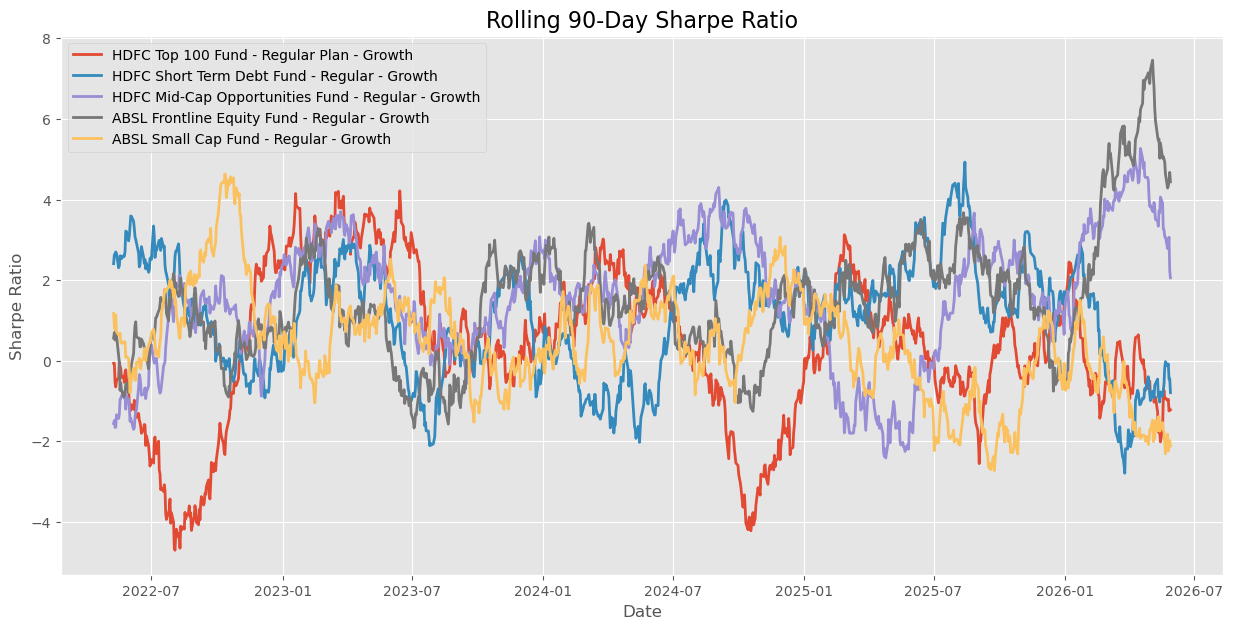

In [15]:
plt.figure(figsize=(15,7))

for fund in top5:

    temp = rolling_sharpe[
        rolling_sharpe["scheme_name"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        linewidth=2,
        label=fund
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio",
    fontsize=16
)

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.legend()

plt.grid(True)

In [16]:
plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [17]:
avg_sharpe = (

    rolling_sharpe

    .groupby(
        "scheme_name"
    )["rolling_sharpe"]

    .mean()

    .reset_index()

)

avg_sharpe = avg_sharpe.sort_values(

    by="rolling_sharpe",

    ascending=False

)

avg_sharpe.head(10)

,scheme_name,rolling_sharpe
17,ICICI Pru Liquid Fund - Regular - Growth,13.558546
23,Kotak Liquid Fund - Regular - Growth,12.478178
1,ABSL Liquid Fund - Regular - Growth,11.995642
22,Kotak Flexicap Fund - Regular - Growth,1.997692
25,Mirae Asset Large Cap Fund - Regular - Growth,1.890422
33,SBI Bluechip Fund - Regular Plan - Growth,1.727788
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.586154
15,ICICI Pru Bluechip Fund - Direct - Growth,1.561429
7,DSP Midcap Fund - Regular - Growth,1.544997
34,SBI Magnum Gilt Fund - Regular Plan - Growth,1.529147


In [18]:
print("Rolling Sharpe Analysis Completed")

print()

print("Funds Plotted")

for fund in top5:

    print("-", fund)

Rolling Sharpe Analysis Completed

Funds Plotted
- HDFC Top 100 Fund - Regular Plan - Growth
- HDFC Short Term Debt Fund - Regular - Growth
- HDFC Mid-Cap Opportunities Fund - Regular - Growth
- ABSL Frontline Equity Fund - Regular - Growth
- ABSL Small Cap Fund - Regular - Growth


### 2. Rolling Sharpe Ratio

Funds maintaining consistently high rolling Sharpe ratios demonstrated superior risk-adjusted performance over time.

In [19]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [20]:
transactions["cohort_year"] = (
    transactions.groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.year
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [22]:
cohort_summary = (

    transactions

    .groupby("cohort_year")

    .agg(

        avg_transaction_amount=("amount_inr", "mean"),

        total_invested=("amount_inr", "sum"),

        investors=("investor_id", "nunique")

    )

    .reset_index()

)

cohort_summary

,cohort_year,avg_transaction_amount,total_invested,investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [23]:
transactions = transactions.merge(

    performance[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

In [24]:
top_fund = (

    transactions

    .groupby(["cohort_year", "scheme_name"])

    .size()

    .reset_index(name="count")

)

top_fund = (

    top_fund

    .sort_values(

        ["cohort_year", "count"],

        ascending=[True, False]

    )

    .drop_duplicates("cohort_year")

)

top_fund

,cohort_year,scheme_name,count
24,2024,Mirae Asset Emerging Bluechip Fund - Regular -...,874
57,2025,ICICI Pru Liquid Fund - Regular - Growth,12


In [25]:
cohort_summary = cohort_summary.merge(

    top_fund[
        ["cohort_year", "scheme_name"]
    ],

    on="cohort_year",

    how="left"

)

cohort_summary.rename(

    columns={
        "scheme_name": "top_fund"
    },

    inplace=True
)

cohort_summary

,cohort_year,avg_transaction_amount,total_invested,investors,top_fund
0,2024,107422.541832,3491125187,4803,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,109158.577061,30455243,197,ICICI Pru Liquid Fund - Regular - Growth


### 3. Investor Cohort Analysis

Recent investor cohorts contributed the highest total investments and preferred diversified equity funds.

In [26]:
sip = transactions[

    transactions["transaction_type"] == "SIP"

].copy()

In [27]:
eligible = (

    sip.groupby("investor_id")

    .size()

)

eligible = eligible[eligible >= 6].index

sip = sip[

    sip["investor_id"].isin(eligible)

]

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,scheme_name
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,Axis Bluechip Fund - Regular - Growth
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024,ABSL Liquid Fund - Regular - Growth
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024,ABSL Liquid Fund - Regular - Growth
8,INV003670,2024-01-01,119120,SIP,10672,Punjab,Chandigarh,T30,36-45,Male,38.4,Net Banking,Verified,2024,SBI Magnum Gilt Fund - Regular Plan - Growth
11,INV001023,2024-01-01,118636,SIP,4865,Gujarat,Ahmedabad,T30,36-45,Male,27.1,Net Banking,Verified,2024,Nippon India Gilt Securities Fund - Regular - ...


In [28]:
sip = sip.sort_values(

    ["investor_id", "transaction_date"]

)

In [29]:
sip["gap_days"] = (

    sip.groupby("investor_id")["transaction_date"]

    .diff()

    .dt.days

)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,scheme_name,gap_days
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,ABSL Liquid Fund - Regular - Growth,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,Axis Small Cap Fund - Regular - Growth,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,Kotak Liquid Fund - Regular - Growth,28.0
12003,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,Mirae Asset Tax Saver Fund - Regular - Growth,59.0
28749,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,DSP Small Cap Fund - Regular - Growth,265.0


In [30]:
sip["gap_days"] = (

    sip.groupby("investor_id")["transaction_date"]

    .diff()

    .dt.days

)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,scheme_name,gap_days
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,ABSL Liquid Fund - Regular - Growth,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,Axis Small Cap Fund - Regular - Growth,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,Kotak Liquid Fund - Regular - Growth,28.0
12003,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,Mirae Asset Tax Saver Fund - Regular - Growth,59.0
28749,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,DSP Small Cap Fund - Regular - Growth,265.0


In [31]:
continuity = (

    sip.groupby("investor_id")

    .agg(

        avg_gap_days=("gap_days", "mean"),

        sip_count=("transaction_date", "count")

    )

    .reset_index()

)

continuity.head()

,investor_id,avg_gap_days,sip_count
0,INV000004,85.400000,6
1,INV000008,70.400000,6
2,INV000010,64.800000,6
3,INV000011,40.166667,7
4,INV000012,57.000000,8


In [32]:
continuity["status"] = np.where(

    continuity["avg_gap_days"] > 35,

    "At-Risk",

    "Healthy"

)

continuity.head()

,investor_id,avg_gap_days,sip_count,status
0,INV000004,85.400000,6,At-Risk
1,INV000008,70.400000,6,At-Risk
2,INV000010,64.800000,6,At-Risk
3,INV000011,40.166667,7,At-Risk
4,INV000012,57.000000,8,At-Risk


In [33]:
print("Healthy Investors :")

print(

    (continuity["status"] == "Healthy").sum()

)

print()

print("At-Risk Investors :")

print(

    (continuity["status"] == "At-Risk").sum()

)

Healthy Investors :
30

At-Risk Investors :
1332


In [34]:
performance["risk_grade"].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [35]:
def recommend_funds(risk):

    result = (

        performance

        [

            performance["risk_grade"]

            .str.lower()

            == risk.lower()

        ]

        .sort_values(

            "sharpe_ratio",

            ascending=False

        )

        [

            [

                "scheme_name",

                "fund_house",

                "category",

                "risk_grade",

                "sharpe_ratio"

            ]

        ]

        .head(3)

    )

    return result

In [36]:
recommend_funds("Low")

,scheme_name,fund_house,category,risk_grade,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Low,7.68
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Low,6.18
30,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Low,5.14


In [37]:
recommend_funds("Moderate")

,scheme_name,fund_house,category,risk_grade,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Moderate,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Moderate,1.03


In [38]:
recommend_funds("High")

,scheme_name,fund_house,category,risk_grade,sharpe_ratio
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,High,0.96
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,High,0.95
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,High,0.90


In [39]:
recommend_funds("Very High")

,scheme_name,fund_house,category,risk_grade,sharpe_ratio
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Very High,0.94
3,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Very High,0.93
29,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Very High,0.90


In [40]:
recommend_funds("Moderately High")

,scheme_name,fund_house,category,risk_grade,sharpe_ratio
13,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,Value,Moderately High,0.98
22,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Moderately High,0.98
33,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Flexi Cap,Moderately High,0.96


### 4. SIP Continuity

Investors with average SIP gaps greater than 35 days were classified as At-Risk, indicating possible discontinuation of investments.

In [41]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [42]:
portfolio["weight_sq"] = (

    portfolio["weight_pct"] / 100

) ** 2

In [43]:
hhi = (

    portfolio

    .groupby("amfi_code")

    .agg(

        HHI=("weight_sq","sum")

    )

    .reset_index()

)

In [44]:
hhi = hhi.merge(

    performance

    [

        [

            "amfi_code",

            "scheme_name",

            "category"

        ]

    ],

    on="amfi_code",

    how="left"

)

hhi.head()

,amfi_code,HHI,scheme_name,category
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Large Cap
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Small Cap
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Index


In [45]:
equity_hhi = hhi[

    hhi["category"]

    .str.contains(

        "Equity",

        case=False,

        na=False

    )

]

equity_hhi = equity_hhi.sort_values(

    "HHI",

    ascending=False

)

equity_hhi.head(10)

,amfi_code,HHI,scheme_name,category


### 5. Sector Concentration (HHI)

Funds with high Herfindahl-Hirschman Index (HHI) values were highly concentrated in a few sectors, increasing concentration risk.